# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium - Wojciech Kot

## Temat:

sieci neuronowe GAN

### Cel ćwiczenia:

Celem laboratorium jest zapoznanie się z sieciami neuronowymi GAN.

### Wykorzystane narzędzia:

Wykorzystane narzędzia i biblioteki:
Środowisko: Google Colab

Język programowania: Python 3
Biblioteki i ich wersje:

Pandas: Wykorzystana do manipulacji danymi, wczytywania plików CSV, grupowania oraz filtrowania rekordów (np. usuwanie duplikatów, sortowanie).

NumPy: Wykorzystany do operacji numerycznych oraz wspomagania filtrowania typów danych w kolumnach.

Matplotlib: Podstawowa biblioteka do generowania wykresów, wykorzystana do personalizacji osi, tytułów oraz tworzenia wykresu liniowego trendów popularności.

Seaborn: Wykorzystana do stworzenia zaawansowanego wykresu relacyjnego (scatter plot), który pozwala na czytelną wizualizację wielu wymiarów danych jednocześnie (energia, głośność, gatunek i popularność).


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# MNIST download fixes (kept from your snippet)
if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']
if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urzadzenie: {device}')


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]

Urzadzenie: cpu


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

In [ ]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

n_epochs = 50
fixed_z = torch.randn(64, latent_dim, device=device)

losses_D = []
losses_G = []

for epoch in range(n_epochs):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        opt_D.zero_grad()


        real_labels = torch.ones(bs, 1, device=device)
        out_real = D(real_imgs)
        loss_real = criterion(out_real, real_labels)


        z = torch.randn(bs, latent_dim, device=device)
        fake_imgs = G(z).detach()
        fake_labels = torch.zeros(bs, 1, device=device)
        out_fake = D(fake_imgs)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()


        opt_G.zero_grad()
        z = torch.randn(bs, latent_dim, device=device)
        gen_imgs = G(z)

        target_for_G = torch.ones(bs, 1, device=device)
        out_gen = D(gen_imgs)
        loss_G = criterion(out_gen, target_for_G)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item() * bs
        epoch_loss_G += loss_G.item() * bs


    N = len(dataloader.dataset)
    losses_D.append(epoch_loss_D / N)
    losses_G.append(epoch_loss_G / N)


    if (epoch + 1) % 10 == 0 or epoch == 0:
        with torch.no_grad():
            fake_grid = G(fixed_z).view(-1, 1, 28, 28)
            grid = vutils.make_grid(fake_grid, nrow=8, normalize=True, value_range=(-1,1))
        plt.figure(figsize=(6,6))
        plt.axis('off')
        plt.title(f'Epoka {epoch+1}')
        plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)), cmap='gray')
        plt.show()

    print(f'Epoka {epoch+1}: L_D={losses_D[-1]:.4f}, L_G={losses_G[-1]:.4f}')


plt.figure()
plt.plot(range(1, n_epochs+1), losses_D, label='L_D')
plt.plot(range(1, n_epochs+1), losses_G, label='L_G')
plt.xlabel('Epoka')
plt.ylabel('Średnia strata')
plt.legend()
plt.title('Straty Dyskryminatora i Generatora')
plt.show()


### Zad 1 -  Ile parametrów ma Generator, ile Dyskryminator? Która warstwa ma ich najwięcej?

Generator - 1 486 325
Dyskryminator - 1 460 225
Najwięcej parametrów ma warstwa Linear(1024 -> 784) w Generatorze (803,600) oraz bardzo podobnie Linear(784 -> 1024) w Dyskryminatorze (803,840); w Generatorze pojedynczo największa to 1024->784.


### Zad 2

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


Urzadzenie: cuda
G(z) shape: torch.Size([16, 784])
D(G(z)) shape: torch.Size([16, 1])
Params Generator: 1486352
Params Discriminator: 1460225


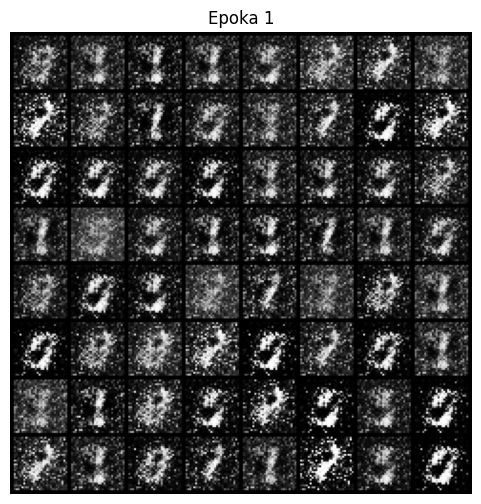

Epoka 1: L_D=0.7408, L_G=2.3550
Epoka 2: L_D=0.5916, L_G=2.8761
Epoka 3: L_D=0.5375, L_G=2.5714
Epoka 4: L_D=0.6649, L_G=2.1253
Epoka 5: L_D=0.7808, L_G=1.7977
Epoka 6: L_D=0.8968, L_G=1.5498
Epoka 7: L_D=0.9580, L_G=1.4234
Epoka 8: L_D=0.9704, L_G=1.3802
Epoka 9: L_D=1.0095, L_G=1.3023


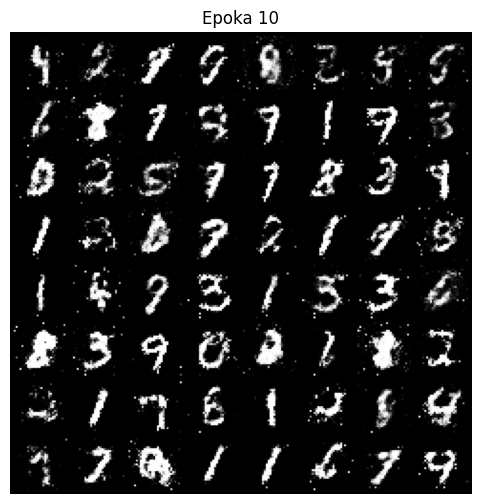

Epoka 10: L_D=1.0263, L_G=1.2769
Epoka 11: L_D=1.0536, L_G=1.2240
Epoka 12: L_D=1.0790, L_G=1.1964
Epoka 13: L_D=1.1072, L_G=1.1455
Epoka 14: L_D=1.1281, L_G=1.1172
Epoka 15: L_D=1.1413, L_G=1.0973
Epoka 16: L_D=1.1532, L_G=1.0778
Epoka 17: L_D=1.1621, L_G=1.0616
Epoka 18: L_D=1.1703, L_G=1.0505
Epoka 19: L_D=1.1745, L_G=1.0474


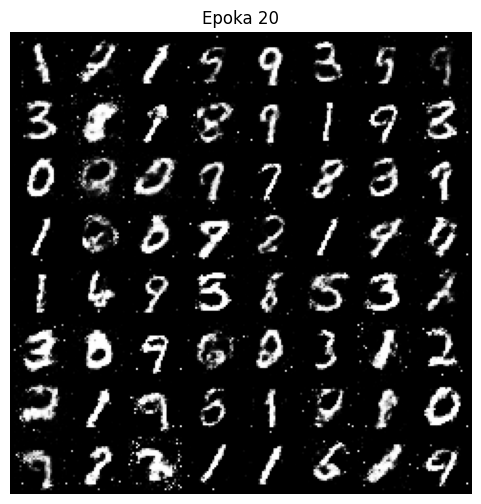

Epoka 20: L_D=1.1807, L_G=1.0351
Epoka 21: L_D=1.1787, L_G=1.0369
Epoka 22: L_D=1.1804, L_G=1.0430
Epoka 23: L_D=1.1840, L_G=1.0301
Epoka 24: L_D=1.1822, L_G=1.0296
Epoka 25: L_D=1.1900, L_G=1.0250
Epoka 26: L_D=1.1930, L_G=1.0196
Epoka 27: L_D=1.1963, L_G=1.0116
Epoka 28: L_D=1.2002, L_G=1.0063
Epoka 29: L_D=1.1999, L_G=1.0013


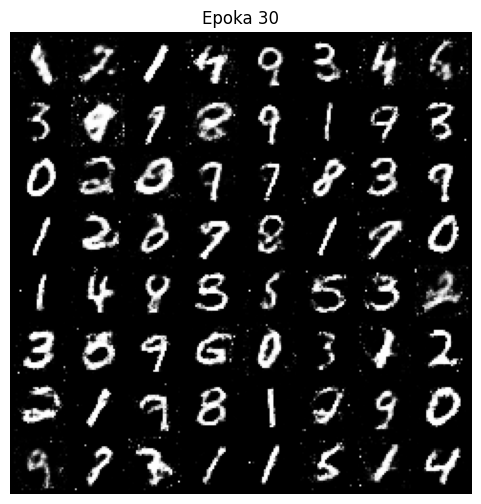

Epoka 30: L_D=1.2026, L_G=0.9962
Epoka 31: L_D=1.2088, L_G=0.9876
Epoka 32: L_D=1.2095, L_G=0.9895
Epoka 33: L_D=1.2037, L_G=0.9983
Epoka 34: L_D=1.2142, L_G=0.9862
Epoka 35: L_D=1.2129, L_G=0.9821
Epoka 36: L_D=1.2156, L_G=0.9815
Epoka 37: L_D=1.2203, L_G=0.9716
Epoka 38: L_D=1.2183, L_G=0.9730
Epoka 39: L_D=1.2203, L_G=0.9726


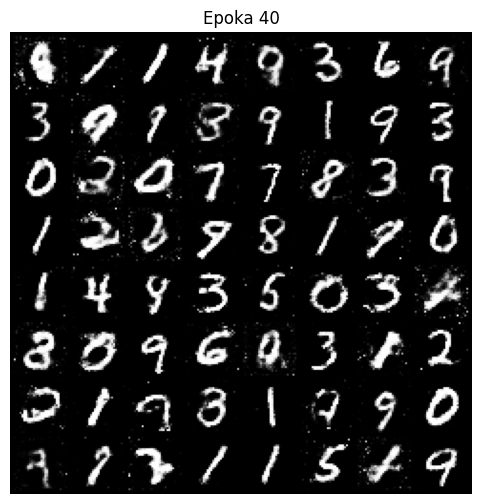

Epoka 40: L_D=1.2217, L_G=0.9723
Epoka 41: L_D=1.2251, L_G=0.9582
Epoka 42: L_D=1.2224, L_G=0.9650
Epoka 43: L_D=1.2261, L_G=0.9652
Epoka 44: L_D=1.2230, L_G=0.9618
Epoka 45: L_D=1.2305, L_G=0.9569
Epoka 46: L_D=1.2269, L_G=0.9552
Epoka 47: L_D=1.2266, L_G=0.9574
Epoka 48: L_D=1.2285, L_G=0.9509
Epoka 49: L_D=1.2288, L_G=0.9545


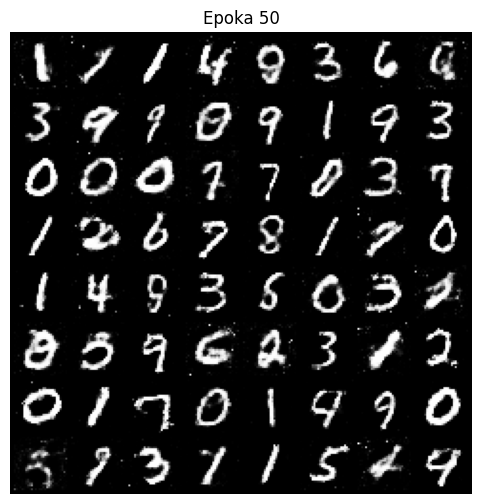

Epoka 50: L_D=1.2345, L_G=0.9454


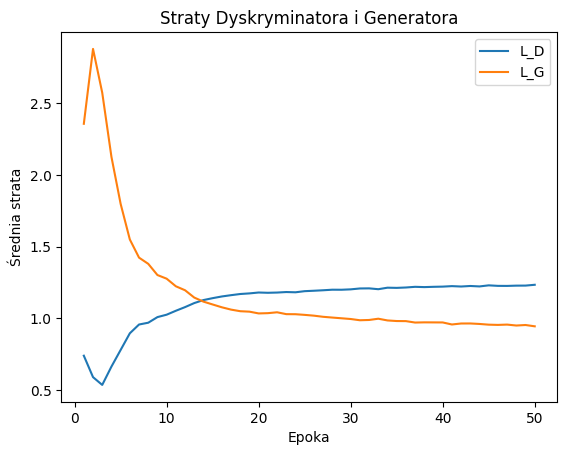

In [ ]:

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np


if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']
if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalizacja do [-1, 1]
])
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urzadzenie: {device}')


class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)


latent_dim = 100
lr = 2e-4
n_epochs = 50

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))


z_test = torch.randn(16, latent_dim, device=device)
gz = G(z_test)
dgz = D(gz)
print('G(z) shape:', gz.shape)    # (16, 784)
print('D(G(z)) shape:', dgz.shape) # (16, 1)


params_G = sum(p.numel() for p in G.parameters())
params_D = sum(p.numel() for p in D.parameters())
print('Params Generator:', params_G)
print('Params Discriminator:', params_D)


fixed_z = torch.randn(64, latent_dim, device=device)
losses_D = []
losses_G = []

for epoch in range(n_epochs):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)


        opt_D.zero_grad()
        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        out_real = D(real_imgs)
        loss_real = criterion(out_real, real_labels)

        z = torch.randn(bs, latent_dim, device=device)
        fake_imgs = G(z).detach()
        out_fake = D(fake_imgs)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()


        opt_G.zero_grad()
        z = torch.randn(bs, latent_dim, device=device)
        gen_imgs = G(z)
        out_gen = D(gen_imgs)

        loss_G = criterion(out_gen, real_labels)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item() * bs
        epoch_loss_G += loss_G.item() * bs

    N = len(dataloader.dataset)
    losses_D.append(epoch_loss_D / N)
    losses_G.append(epoch_loss_G / N)


    if (epoch + 1) % 10 == 0 or epoch == 0:
        with torch.no_grad():
            fake_grid = G(fixed_z).view(-1, 1, 28, 28)
            grid = vutils.make_grid(fake_grid, nrow=8, normalize=True, value_range=(-1,1))
        plt.figure(figsize=(6,6))
        plt.axis('off')
        plt.title(f'Epoka {epoch+1}')
        plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)), cmap='gray')
        plt.show()

    print(f'Epoka {epoch+1}: L_D={losses_D[-1]:.4f}, L_G={losses_G[-1]:.4f}')


plt.figure()
plt.plot(range(1, n_epochs+1), losses_D, label='L_D')
plt.plot(range(1, n_epochs+1), losses_G, label='L_G')
plt.xlabel('Epoka')
plt.ylabel('Średnia strata')
plt.legend()
plt.title('Straty Dyskryminatora i Generatora')
plt.show()


### Zad 2 - kiedy wygenerowane cyfry stają się po raz pierwszy rozpoznawalne? Jak zachowują się straty w kolejnych epokach?  

Wygenerowane cyfry stają się w większości rozpoznawalne w ok. 10 epoce treningu.

Straty Dyskryminatora spadają nieco w pierwszych 2-3 epokach aby potem nieco urosnąć i ustabilizować się koło 15 epoki na poziomie nieco ponad 1.0

Straty generatora poczatkowo odrobinę rosną aby gwałtownie spadnąć i ustabilizować się z lekkim, progresywnym spadkiem na poziomie około 1.0 po 12-13 epoce



### Zad 3 - Eksploracja przestrzeni Latentnej

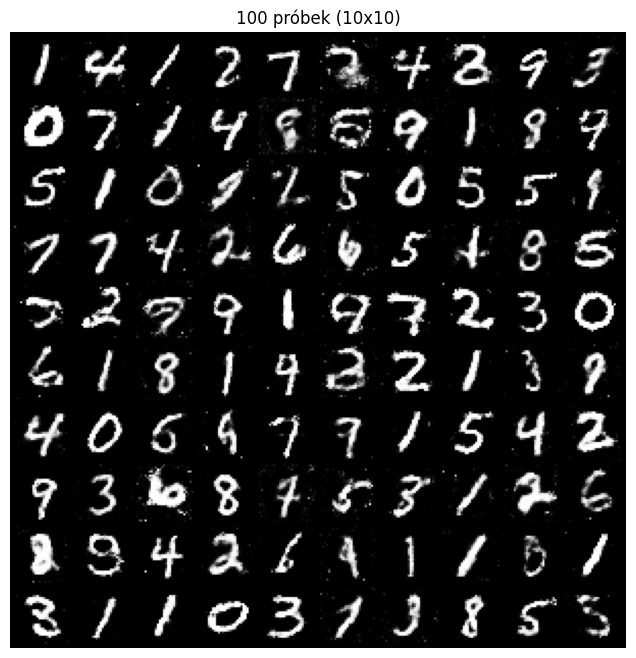

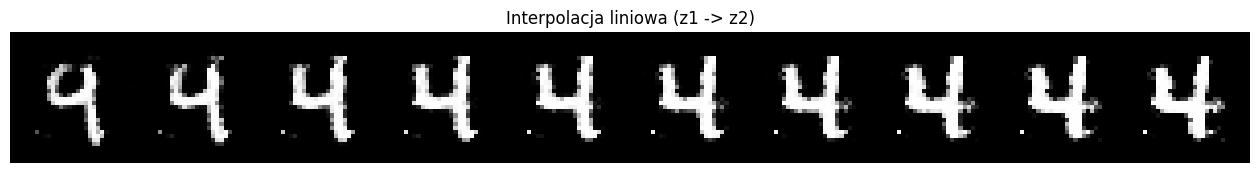

In [ ]:

import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np



latent_dim = 100


with torch.no_grad():
    z100 = torch.randn(100, latent_dim, device=device)
    imgs100 = G(z100).view(-1, 1, 28, 28)
    grid100 = vutils.make_grid(imgs100, nrow=10, normalize=True, value_range=(-1,1))
plt.figure(figsize=(8,8))
plt.axis('off')
plt.title('100 próbek (10x10)')
plt.imshow(np.transpose(grid100.cpu().numpy(), (1,2,0)), cmap='gray')
plt.show()


with torch.no_grad():
    z1 = torch.randn(1, latent_dim, device=device)
    z2 = torch.randn(1, latent_dim, device=device)
    steps = 10
    ts = torch.linspace(0, 1, steps, device=device)
    interp = torch.stack([(1 - t) * z1 + t * z2 for t in ts]).squeeze(1)  # shape (steps, latent_dim)
    imgs_interp = G(interp).view(-1, 1, 28, 28)
    grid_interp = vutils.make_grid(imgs_interp, nrow=steps, normalize=True, value_range=(-1,1))
plt.figure(figsize=(16,2))
plt.axis('off')
plt.title('Interpolacja liniowa (z1 -> z2)')
plt.imshow(np.transpose(grid_interp.cpu().numpy(), (1,2,0)), cmap='gray')
plt.show()


from PIL import Image
grid_img = (255 * (np.transpose(grid100.cpu().numpy(), (1,2,0)))).astype(np.uint8)
Image.fromarray(grid_img).save('samples_100.png')


co obserwujesz przy interpolacji? Czy przejścia między cyframi są
gładkie? Co to mówi o strukturze przestrzeni latentnej?

Zmiany są drobny i płynne. Różne wektory latentne mogą mapować do tej samej „mody” obrazu; może występować ograniczona różnorodność lub częściowy mode collapse.